In [ ]:
import torch
import random
import matplotlib.pyplot as plt
import torch.nn.functional as F
import sys
sys.path.append('../')

from src.datasets.epic_sounds import EPICSoundsDataset
from src.models.ast import EPICASTBaseline

print("Caricamento del modello e dei dati in corso...")

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = EPICASTBaseline(num_classes=44)
model.load_state_dict(torch.load("../experiments/checkpoints/best_ast_baseline.pth", map_location=device))
model.to(device)
model.eval()

val_dataset = EPICSoundsDataset(
    annotations_file="../data/epic-sounds-annotations/EPIC_Sounds_validation.csv",
    hdf5_path="../data/EPIC_audio.hdf5"
)

print(f"Modello pronto. Trovati {len(val_dataset)} audio di validazione.")

🤖 Caricamento del modello e dei dati in corso...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.dense.weight     | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/var/folders/_z/750_rmjs0gvdkw27vs5017dc0000gn/T/ipykernel_62786/2442303309.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the 

✅ Modello pronto! Trovati 8035 audio di validazione. Ora puoi eseguire la Cella 2.


Classe Reale: 9
Prima Scelta: Classe 4 (41.7%)
Seconda Scelta: Classe 1 (36.3%)
Terza Scelta: Classe 9 (10.8%)


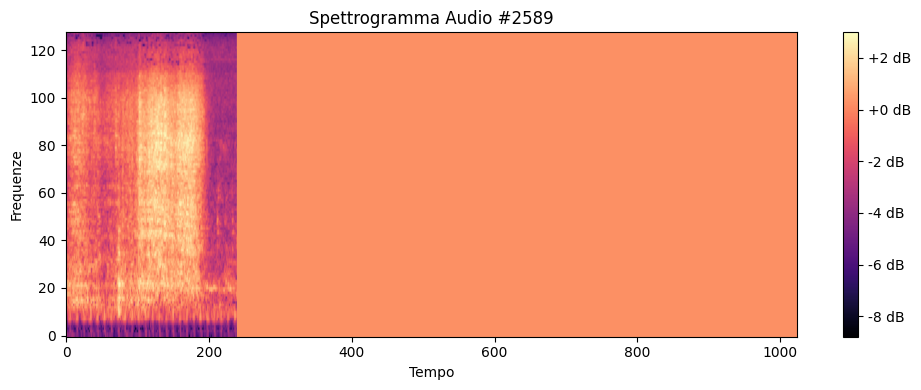

In [23]:
random_idx = random.randint(0, len(val_dataset) - 1)
audio_spectrogram, true_label = val_dataset[random_idx]

with torch.no_grad():
    output = model(audio_spectrogram.unsqueeze(0).to(device))
    probabilities = F.softmax(output, dim=1)[0] * 100

top3_prob, top3_classes = torch.topk(probabilities, 3)
predicted_label = top3_classes[0].item()

print("="*40)
print(f"Classe Reale: {true_label}")
print(f"Prima Scelta: Classe {predicted_label} ({top3_prob[0]:.1f}%)")
print(f"Seconda Scelta: Classe {top3_classes[1].item()} ({top3_prob[1]:.1f}%)")
print(f"Terza Scelta: Classe {top3_classes[2].item()} ({top3_prob[2]:.1f}%)")
print("="*40)

plt.figure(figsize=(10, 4))

plt.imshow(audio_spectrogram[0].cpu().numpy(), aspect='auto', origin='lower', cmap='magma')
plt.title(f"Spettrogramma Audio #{random_idx}")
plt.ylabel("Frequenze")
plt.xlabel("Tempo")
plt.colorbar(format='%+2.0f dB')
plt.tight_layout()
plt.show()

In [25]:
import torch
import time
import os

print("Avvio Benchmark AST Baseline...\n")

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("STATISTICHE PARAMETRI:")
print(f"- Parametri Totali: {total_params:,}")
print(f"- Parametri Addestrabili (grazie al Freezing): {trainable_params:,}\n")

checkpoint_path = "../experiments/checkpoints/best_ast_baseline.pth"
if os.path.exists(checkpoint_path):
    size_mb = os.path.getsize(checkpoint_path) / (1024 * 1024)
    print("PESO DEL MODELLO:")
    print(f"- Dimensione file .pth: {size_mb:.2f} MB\n")
else:
    print("PESO DEL MODELLO: File non trovato per il calcolo dei MB.\n")


print("TEST LATENZA E VELOCITÀ...")

dummy_input = torch.randn(1, 1, 128, 1024).to(device)

# WARM-UP: Facciamo fare qualche giro a vuoto al modello.
with torch.no_grad():
    for _ in range(10):
        _ = model(dummy_input)

# MISURAZIONE VERA E PROPRIA
iterations = 100
start_time = time.perf_counter()

with torch.no_grad():
    for _ in range(iterations):
        _ = model(dummy_input)
        
end_time = time.perf_counter()


avg_time_ms = ((end_time - start_time) / iterations) * 1000
fps = 1000 / avg_time_ms

print(f"- Tempo medio di elaborazione per 1 audio: {avg_time_ms:.2f} millisecondi")
print(f"- Audio processati al secondo (FPS): {fps:.1f}")
print("\nBenchmark completato. Salva questi numeri per la relazione!")

Avvio Benchmark AST Baseline...

STATISTICHE PARAMETRI:
- Parametri Totali: 86,221,100
- Parametri Addestrabili (grazie al Freezing): 14,211,116

PESO DEL MODELLO:
- Dimensione file .pth: 328.99 MB

TEST LATENZA E VELOCITÀ...
- Tempo medio di elaborazione per 1 audio: 320.63 millisecondi
- Audio processati al secondo (FPS): 3.1

Benchmark completato. Salva questi numeri per la relazione!
